In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("house_prices.csv")

df

,area_sqft,bedrooms,bathrooms,age_years,distance_to_city_km,price_lakh
0,850,2,1,10,12,35
1,900,2,2,8,10,42
2,1200,3,2,5,8,65
3,1500,3,3,2,6,85
4,1800,4,3,1,5,110
5,2000,4,4,3,4,130
6,750,1,1,15,15,28
7,950,2,2,7,9,50
8,1100,3,2,6,7,60
9,1400,3,3,4,6,78


<h1>Multiple Linear Regression</h1>

X     area_sqft  bedrooms  bathrooms  age_years  distance_to_city_km
0         850         2          1         10                   12
1         900         2          2          8                   10
2        1200         3          2          5                    8
3        1500         3          3          2                    6
4        1800         4          3          1                    5
5        2000         4          4          3                    4
6         750         1          1         15                   15
7         950         2          2          7                    9
8        1100         3          2          6                    7
9        1400         3          3          4                    6
10       1700         4          3          2                    5
11       2100         5          4          1                    3
12        650         1          1         20                   18
13        800         2          1         12               

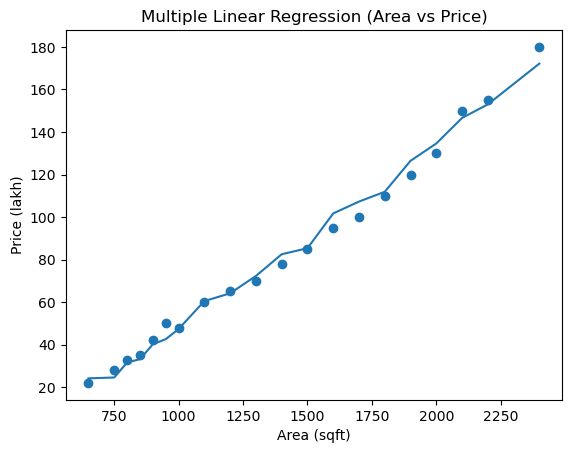

In [20]:
X = df.drop('price_lakh', axis = 1)
y = df['price_lakh']

print("X", X)
print("Y", y)
# X
# y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2
)

model = LinearRegression()
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

print()
print("Y Predict", y_predict)
print()

mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
rmse = np.sqrt(mean_squared_error(y_test, y_predict))

print("MAE : ", mae)
print("RMSE : ", rmse)
print("MSE:", mse)
print("R2 Score:", r2)

plt.figure()

plt.scatter(df['area_sqft'], df['price_lakh'])

sorted_idx = df['area_sqft'].argsort()

plt.plot(
    df['area_sqft'].iloc[sorted_idx],
    model.predict(X)[sorted_idx],
)

plt.xlabel("Area (sqft)")
plt.ylabel("Price (lakh)")
plt.title("Multiple Linear Regression (Area vs Price)")

plt.show()

<h1>Polynomial Regression</h1>

MSE :  13.790875099014734
R2 :  0.9902795594015755


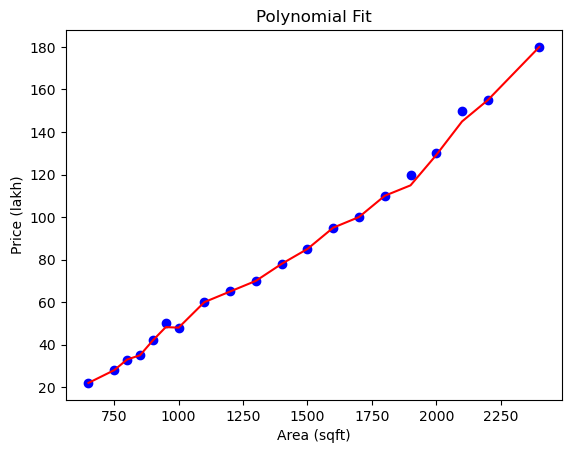

In [11]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size = 0.2
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print("MSE : ", mse)
# print("MAE : ", mae)
# print("RMSE : ", rmse)
print("R2 : ", r2)

plt.scatter(df['area_sqft'], df['price_lakh'], color='blue')

# sort for smooth line
sorted_idx = df['area_sqft'].argsort()
plt.plot(df['area_sqft'].iloc[sorted_idx],
         model.predict(X_poly)[sorted_idx],
         color='red')

plt.xlabel("Area (sqft)")
plt.ylabel("Price (lakh)")
plt.title("Polynomial Fit")
plt.show()